#**Product Review Sentiment Analysis**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob
import warnings
warnings.filterwarnings("ignore")
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
#Load Data set
df = pd.read_excel("P652-Dataset.xlsx")

In [ ]:
print(df.head())

                                     title  rating  \
0                         Horrible product       1   
1  Camera quality is not like 48 megapixel       3   
2                                  Overall       4   
3                         A big no from me       1   
4            Put your money somewhere else       1   

                                                body  
0  Very disappointed with the overall performance...  
1                              Camera quality is low  
2  Got the mobile on the launch date,Battery must...  
3  1. It doesn't work with 5.0GHz WiFi frequency....  
4  Not worth buying....faulty software, poor disp...  


In [ ]:
df.shape

(1440, 3)

In [ ]:
df.columns

Index(['title', 'rating', 'body'], dtype='object')

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB
None


In [ ]:
df.isna().sum()

,0
title,0
rating,0
body,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print(df.describe())

            rating
count  1440.000000
mean      3.173611
std       1.584453
min       1.000000
25%       1.000000
50%       4.000000
75%       5.000000
max       5.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["review"] = df["title"] + " " + df["body"]

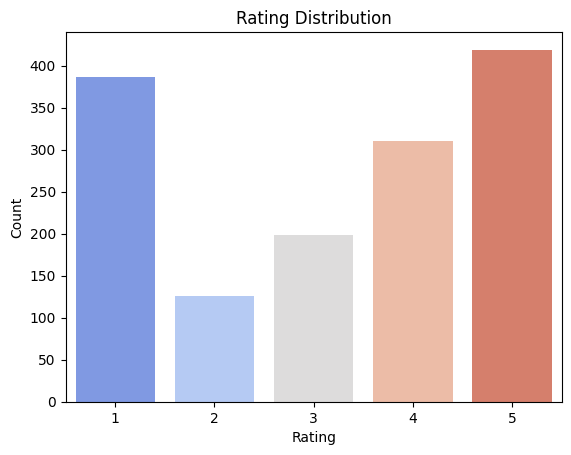

In [ ]:
#Rating Distribution
plt.figure()
sns.countplot(x=df['rating'],palette='coolwarm')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [ ]:
print("Average Rating:", round(df['rating'].mean(),2))

Average Rating: 3.17


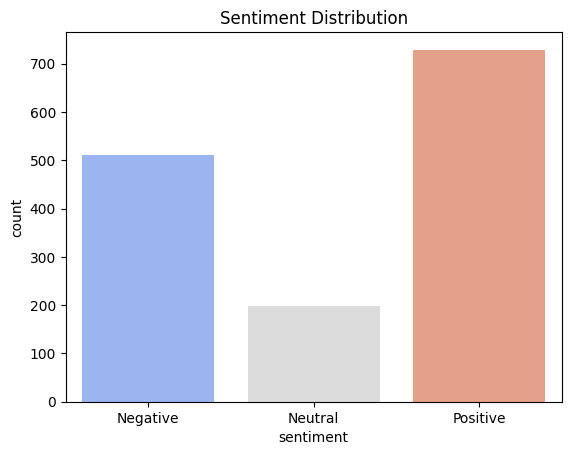

In [ ]:
#Sentiment Distribution
def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df['sentiment'] = df['rating'].apply(sentiment_label)

sns.countplot(x=df['sentiment'],palette='coolwarm')
plt.title("Sentiment Distribution")
plt.show()

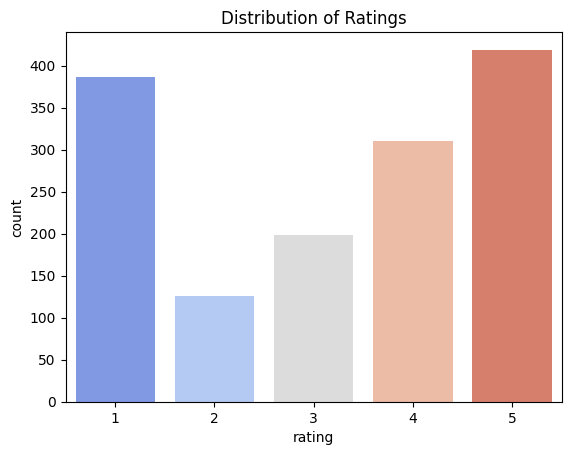

In [ ]:
#Distribution Of Ratings
sns.countplot(x='rating', data=df, palette='coolwarm')
plt.title("Distribution of Ratings")
plt.show()


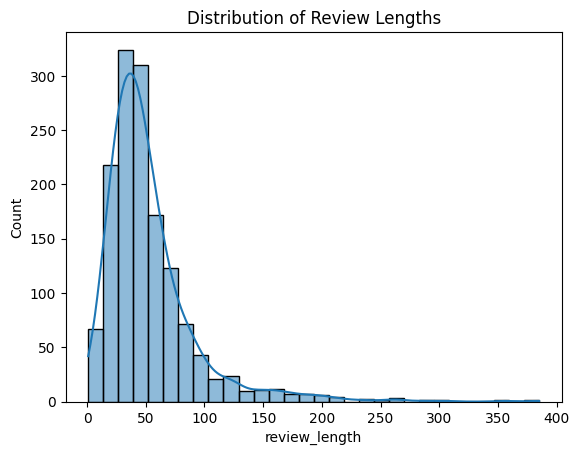

In [ ]:
#Distribution of Review Lengths
df['review_length'] = df['body'].apply(lambda x: len(str(x).split()))

sns.histplot(df['review_length'], bins=30, kde=True)
plt.title("Distribution of Review Lengths")
plt.show()

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

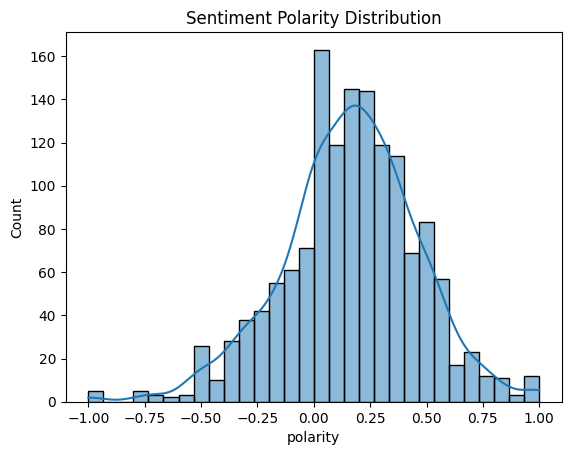

In [ ]:
from textblob import TextBlob

df['polarity'] = df['body'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

sns.histplot(df['polarity'], bins=30, kde=True)
plt.title("Sentiment Polarity Distribution")
plt.show()


##TEXT EDA (Customer Behavior Analysis)

##Text Cleaning

In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z ]","",text)
    return text

df["review"] = df["review"].apply(clean_text)

##Convert Text → Numbers
We convert text using TF‑IDF.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")

X = vectorizer.fit_transform(df["review"])
y = df["sentiment"]

##Feature Engineering

In [ ]:
df['title_length'] = df['title'].apply(len)
df['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()))

In [ ]:
df['rating_normalized'] = df['rating'] / 5

##Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

##**Model Building**

###Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

###Naive Bayes Classifier

In [ ]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

###Random Forest

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

###Support Vector Machine (SVM)

In [ ]:
svm = LinearSVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

###XGBoost / Gradient Boosting

In [ ]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train_encoded)
y_pred = xgb_model.predict(X_test)

##Model Evaluation

In [ ]:
accuracy_results = {
    "Naive Bayes": accuracy_score(y_test, nb_pred),
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "SVM": accuracy_score(y_test, svm_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "XGBoost": accuracy_score(y_test_encoded, y_pred)
}

accuracy_df = pd.DataFrame(list(accuracy_results.items()),
                           columns=["Model","Accuracy"])

print(accuracy_df)

                 Model  Accuracy
0          Naive Bayes  0.694444
1  Logistic Regression  0.788194
2                  SVM  0.795139
3        Random Forest  0.774306
4              XGBoost  0.767361


##Model Accuracy Comparison

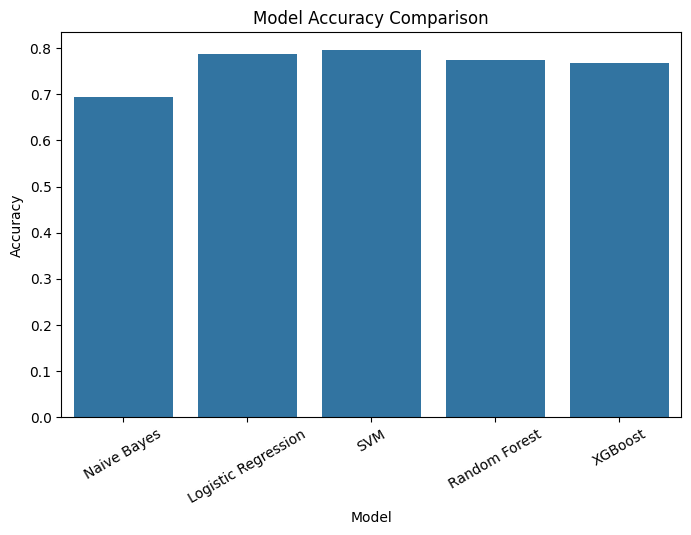

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=accuracy_df)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.show()

In [ ]:
print("Naive Bayes Classification Report\n")
print(classification_report(y_test, nb_pred))

Naive Bayes Classification Report

              precision    recall  f1-score   support

    Negative       0.97      0.61      0.75       111
     Neutral       0.00      0.00      0.00        44
    Positive       0.61      0.99      0.75       133

    accuracy                           0.69       288
   macro avg       0.53      0.54      0.50       288
weighted avg       0.65      0.69      0.64       288



In [ ]:
print("Logistic Regression Classification Report\n")
print(classification_report(y_test, lr_pred))

Logistic Regression Classification Report

              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87       111
     Neutral       1.00      0.02      0.04        44
    Positive       0.73      0.98      0.84       133

    accuracy                           0.79       288
   macro avg       0.87      0.62      0.58       288
weighted avg       0.83      0.79      0.73       288



In [ ]:
print("SVM Classification Report\n")
print(classification_report(y_test, svm_pred))

SVM Classification Report

              precision    recall  f1-score   support

    Negative       0.87      0.86      0.87       111
     Neutral       0.50      0.11      0.19        44
    Positive       0.76      0.96      0.85       133

    accuracy                           0.80       288
   macro avg       0.71      0.65      0.63       288
weighted avg       0.76      0.80      0.76       288



In [ ]:
print("Random Forest Classification Report\n")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report

              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87       111
     Neutral       0.00      0.00      0.00        44
    Positive       0.71      0.96      0.82       133

    accuracy                           0.77       288
   macro avg       0.53      0.61      0.56       288
weighted avg       0.67      0.77      0.71       288



In [ ]:
print("XGBoost Classification Report\n")
print(classification_report(y_test_encoded, y_pred))

XGBoost Classification Report

              precision    recall  f1-score   support

           0       0.84      0.82      0.83       111
           1       0.44      0.16      0.23        44
           2       0.75      0.92      0.83       133

    accuracy                           0.77       288
   macro avg       0.68      0.63      0.63       288
weighted avg       0.74      0.77      0.74       288



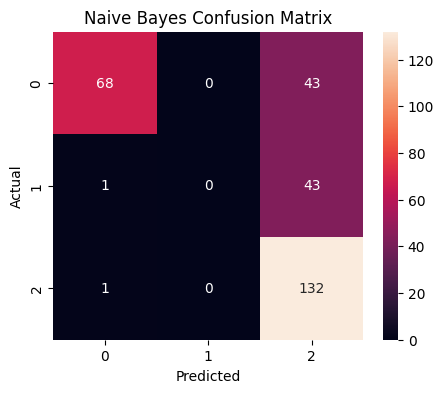

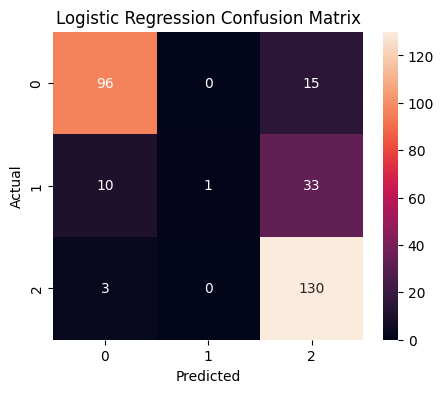

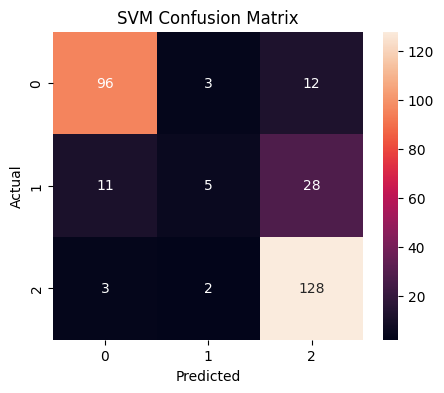

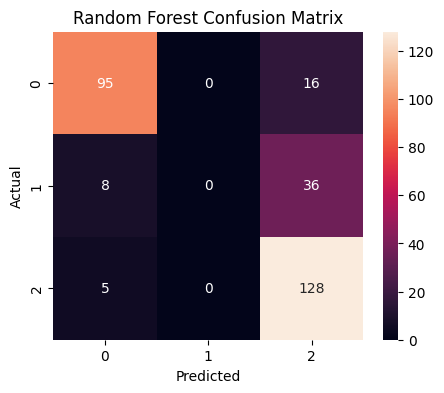

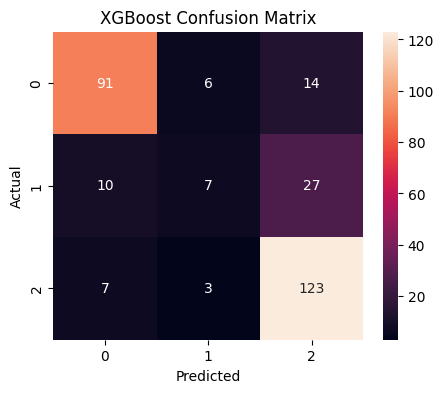

In [ ]:
models = {
    "Naive Bayes": nb_pred,
    "Logistic Regression": lr_pred,
    "SVM": svm_pred,
    "Random Forest": rf_pred,
    "XGBoost" : y_pred
}

for name, pred in models.items():

    # Use y_test_encoded for XGBoost, otherwise use original y_test
    if name == "XGBoost":
        true_labels = y_test_encoded
    else:
        true_labels = y_test

    cm = confusion_matrix(true_labels, pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

##Deployment

In [ ]:
import pickle

# SVM performed best — saving as production model
with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(svm, f)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("sentiment_model.pkl saved")
print("tfidf_vectorizer.pkl saved")

sentiment_model.pkl saved
tfidf_vectorizer.pkl saved


In [ ]:
with open("sentiment_model.pkl", "rb") as f:
    _model = pickle.load(f)
with open("tfidf_vectorizer.pkl", "rb") as f:
    _vec = pickle.load(f)

samples = [
    "Absolutely love this product, works perfectly!",
    "It is average, nothing special.",
    "Terrible. Broke on day one. Total waste of money."
]
for s in samples:
    p = _model.predict(_vec.transform([clean_text(s)]))[0]
    print(f"{p:10s} | {s}")

Positive   | Absolutely love this product, works perfectly!
Neutral    | It is average, nothing special.
Negative   | Terrible. Broke on day one. Total waste of money.


In [ ]:
!pip install streamlit pyngrok -q
print("Installed: streamlit, pyngrok")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 93.3 MB/s eta 0:00:00
Installed: streamlit, pyngrok


In [ ]:
app_code = "import streamlit as st\nimport pickle, re\nimport pandas as pd\n\nst.set_page_config(page_title=\"Sentiment Analyzer\", page_icon=\"\\U0001f4ac\", layout=\"centered\")\n\n@st.cache_resource\ndef load_model():\n    with open(\"sentiment_model.pkl\", \"rb\") as f:\n        model = pickle.load(f)\n    with open(\"tfidf_vectorizer.pkl\", \"rb\") as f:\n        vec = pickle.load(f)\n    return model, vec\n\nmodel, vectorizer = load_model()\n\ndef clean_text(text):\n    text = text.lower()\n    import re\n    text = re.sub(r\"[^a-zA-Z ]\", \"\", text)\n    return text\n\nCFG = {\n    \"Positive\": {\"emoji\": \"\\U0001f60a\", \"color\": \"#22c55e\", \"bg\": \"#f0fdf4\"},\n    \"Neutral\":  {\"emoji\": \"\\U0001f610\", \"color\": \"#f59e0b\", \"bg\": \"#fffbeb\"},\n    \"Negative\": {\"emoji\": \"\\U0001f620\", \"color\": \"#ef4444\", \"bg\": \"#fef2f2\"},\n}\n\nst.title(\"\\U0001f4ac Product Review Sentiment Analyzer\")\nst.caption(\"SVM + TF-IDF | NLP Final Project\")\nst.markdown(\"---\")\n\nmode = st.radio(\"Mode\", [\"Single review\", \"Batch reviews\"], horizontal=True)\n\nif mode == \"Single review\":\n    user_input = st.text_area(\"Enter a product review\", height=140,\n                              placeholder=\"e.g. This product is amazing!\")\n    if st.button(\"Analyze\", use_container_width=True):\n        if not user_input.strip():\n            st.warning(\"Please enter a review.\")\n        else:\n            pred = model.predict(vectorizer.transform([clean_text(user_input)]))[0]\n            c = CFG[pred]\n            st.markdown(\n                '<div style=\"background:' + c[\"bg\"] + ';border-left:4px solid ' + c[\"color\"] + ';'\n                'padding:1.2rem 1.5rem;border-radius:8px;margin-top:1rem;\">'\n                '<span style=\"font-size:2rem;\">' + c[\"emoji\"] + '</span>'\n                '<span style=\"font-size:1.4rem;font-weight:600;color:' + c[\"color\"] + ';margin-left:.5rem;\">' + pred + '</span>'\n                '<p style=\"color:#555;margin:.4rem 0 0;\">Classified as <b>' + pred.lower() + '</b>.</p></div>',\n                unsafe_allow_html=True\n            )\n\nelse:\n    batch = st.text_area(\"Enter reviews (one per line)\", height=200)\n    if st.button(\"Analyze All\", use_container_width=True):\n        if not batch.strip():\n            st.warning(\"Please enter at least one review.\")\n        else:\n            rows = [r.strip() for r in batch.strip().split(\"\\n\") if r.strip()]\n            results = []\n            for r in rows:\n                pred = model.predict(vectorizer.transform([clean_text(r)]))[0]\n                results.append({\"Review\": r[:80], \"Sentiment\": CFG[pred][\"emoji\"] + \" \" + pred})\n            st.dataframe(pd.DataFrame(results), use_container_width=True)\n            counts = {}\n            for res in results:\n                lbl = res[\"Sentiment\"].split(\" \")[1]\n                counts[lbl] = counts.get(lbl, 0) + 1\n            cols = st.columns(len(counts))\n            for col, (lbl, cnt) in zip(cols, counts.items()):\n                col.metric(CFG[lbl][\"emoji\"] + \" \" + lbl, cnt)\n\nst.markdown(\"---\")\nst.caption(\"NLP Final Project\")\n"

with open("app.py", "w") as f:
    f.write(app_code)
print("app.py written!")


app.py written!


In [ ]:
import subprocess, threading, time
from pyngrok import ngrok, conf

# for authtokens- https://dashboard.ngrok.com/get-started/your-authtoken
NGROK_TOKEN = "3Asx8fpO2QfPMrtyawt2amk3JWe_voYAYuoJioRAJnyZiyiz"

conf.get_default().auth_token = NGROK_TOKEN

# Start Streamlit in background
proc = subprocess.Popen(
    ["streamlit", "run", "app.py",
     "--server.port=8501",
     "--server.headless=true",
     "--server.enableCORS=false"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)
time.sleep(4)   # wait for streamlit to start

# Open ngrok tunnel
public_url = ngrok.connect(8501)
print("=" * 95)
print(f"  The Streamlit app is LIVE at:")
print(f"  {public_url}")
print("=" * 95)

  The Streamlit app is LIVE at:
  NgrokTunnel: "https://unfended-nonsuggestively-sudie.ngrok-free.dev" -> "http://localhost:8501"
